IRIS DATASET LOADED SUCCESSFULLY
Rows    : 150
Columns : 5

DATA QUALITY REPORT
Duplicate Records : 3
Missing Values    : 0
3 duplicate rows removed.
Final Shape : (147, 5)

Quality Report
             Data Type  Missing Values  Unique Values
sepal_length   float64               0             35
sepal_width    float64               0             23
petal_length   float64               0             43
petal_width    float64               0             22
species         object               0              3

Statistical Summary
       sepal_length  sepal_width  petal_length  petal_width
count    147.000000   147.000000    147.000000   147.000000
mean       5.856463     3.055782      3.780272     1.208844
std        0.829100     0.437009      1.759111     0.757874
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.400000     1.300000
75%        6.400000     3.300000      5.100000

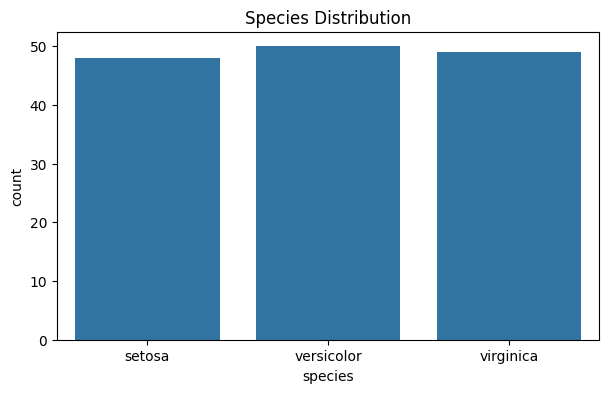


Species Percentage
species
versicolor    34.013605
virginica     33.333333
setosa        32.653061
Name: proportion, dtype: float64


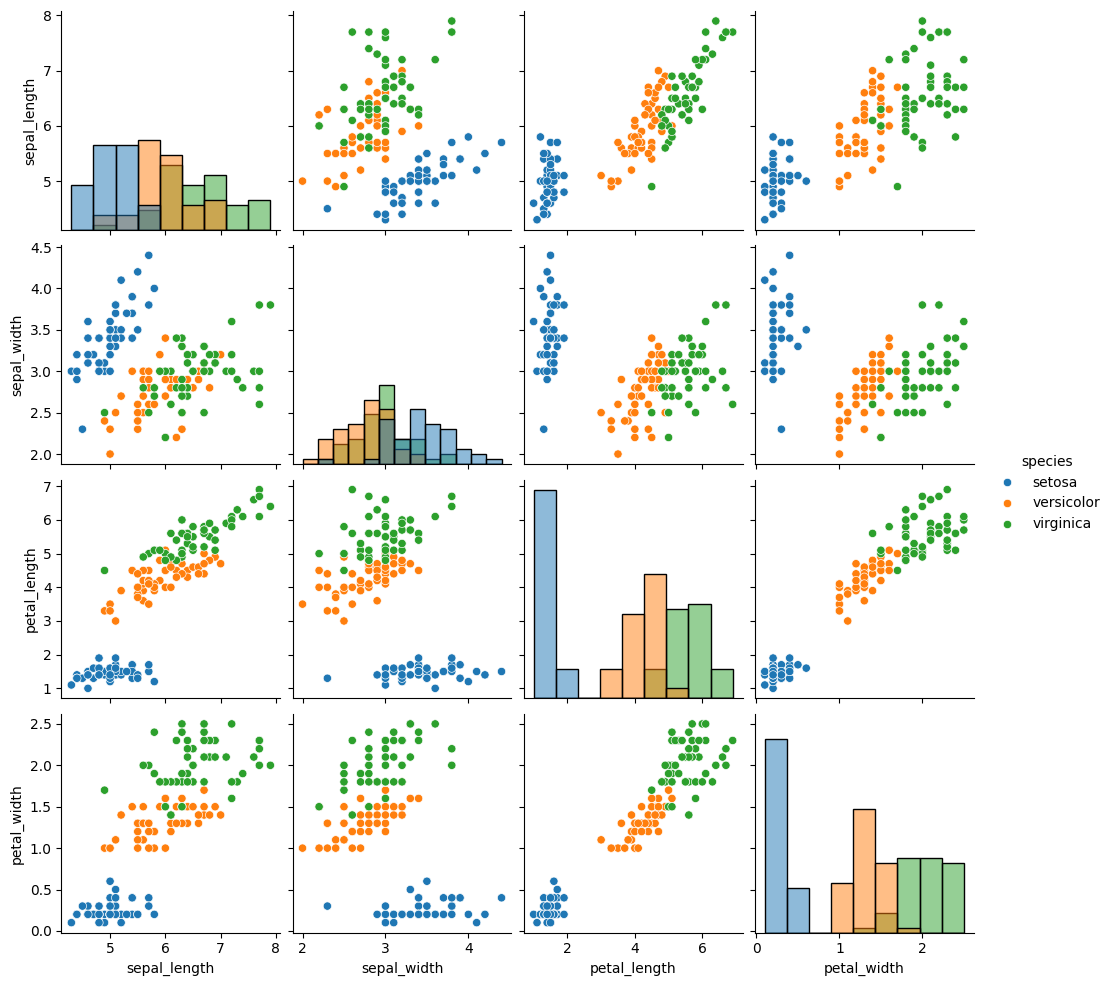

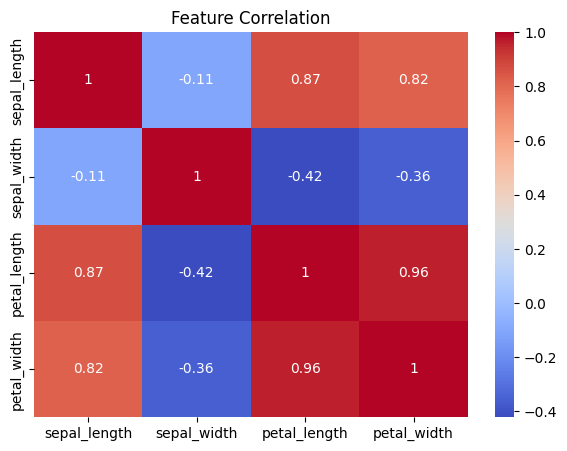

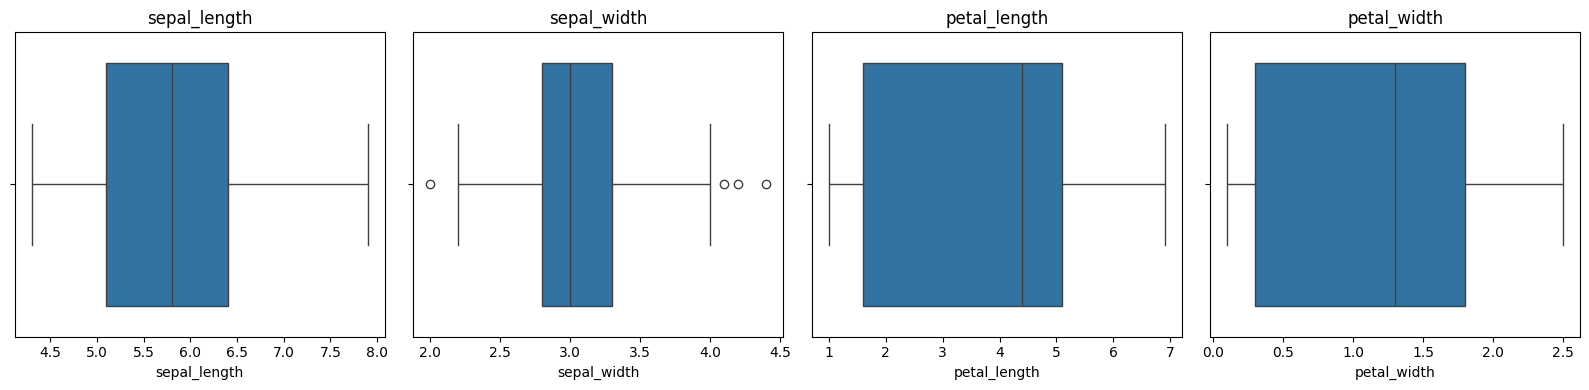


Class Mapping
0 -> setosa
1 -> versicolor
2 -> virginica

Feature Matrix Shape : (147, 4)
Target Vector Shape  : (147,)

Train Test Split
X_train : (117, 4)
X_test  : (30, 4)

MODEL COMPARISON
Logistic Regression       Accuracy = 0.9572 (+/- 0.0381)
Support Vector Machine    Accuracy = 0.9659 (+/- 0.0417)
Random Forest             Accuracy = 0.9656 (+/- 0.0324)

Model Ranking
                    Model  Accuracy
1  Support Vector Machine  0.965942
2           Random Forest  0.965580
0     Logistic Regression  0.957246


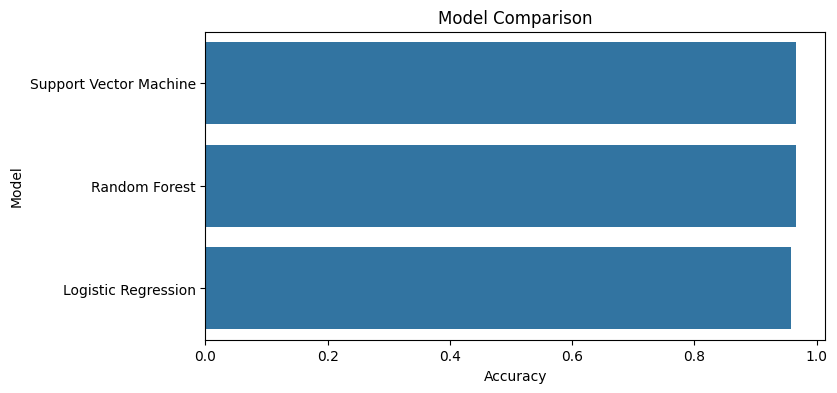


Best Model Selected:
Support Vector Machine

Sample Predictions
  Actual Species Predicted Species
0     versicolor        versicolor
1     versicolor        versicolor
2      virginica         virginica
3         setosa            setosa
4      virginica         virginica
5     versicolor         virginica
6     versicolor        versicolor
7         setosa            setosa
8      virginica         virginica
9      virginica         virginica

MODEL PERFORMANCE

Accuracy Score : 0.9667

Cross Validation Accuracy : 0.9660

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



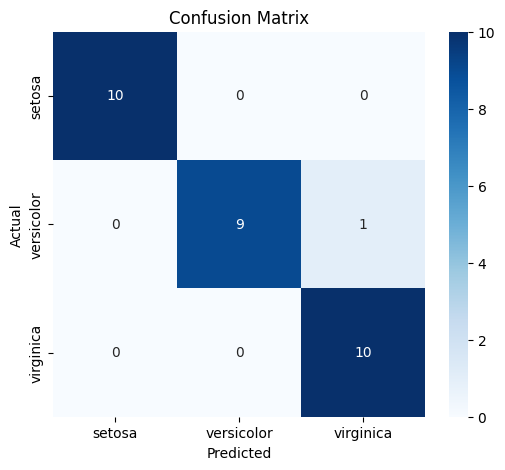


Feature Importance
        Feature  Importance
2  petal_length    0.448666
3   petal_width    0.409583
0  sepal_length    0.119885
1   sepal_width    0.021867


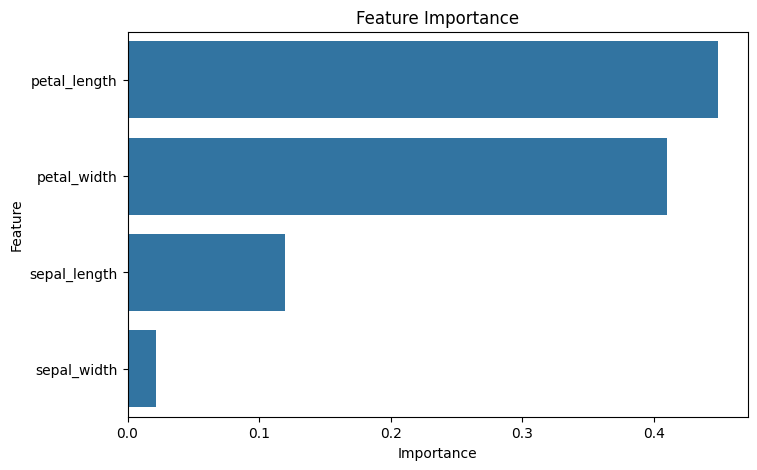


Sample Flower Prediction
Predicted Species : setosa

Model Saved Successfully
File Name : iris_classifier.pkl

PROJECT SUMMARY
                      Metric     Value
0                   Accuracy    0.9667
1  Cross Validation Accuracy    0.9660
2         Number of Features    4.0000
3          Number of Classes    3.0000
4           Training Samples  117.0000
5            Testing Samples   30.0000

Top Correct Predictions
  Actual Species Predicted Species
0     versicolor        versicolor
1     versicolor        versicolor
2      virginica         virginica
3         setosa            setosa
4      virginica         virginica

Task 3 Completed Successfully!


In [7]:

# CODSOFT : DATA SCIENCE
# TASK 3 : IRIS FLOWER CLASSIFICATION
# AUTHOR : SALIK KHAN


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# LOAD DATASET


DATA_URL = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(DATA_URL)

print("="*60)
print("IRIS DATASET LOADED SUCCESSFULLY")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()

# DATA QUALITY REPORT

print("DATA QUALITY REPORT")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")
print(f"Missing Values    : {df.isnull().sum().sum()}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicates} duplicate rows removed.")

print(f"Final Shape : {df.shape}")

quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

print("\nQuality Report")
print(quality_report)

# STATISTICAL SUMMARY

print("\nStatistical Summary")
print(df.describe())

# SPECIES DISTRIBUTION

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Species Distribution")
plt.show()

species_percent = (
    df["species"]
    .value_counts(normalize=True)
    * 100
)

print("\nSpecies Percentage")
print(species_percent)

# PAIRPLOT

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()


# HEATMAP

plt.figure(figsize=(7,5))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

# BOXPLOTS

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,4)
)

for i, col in enumerate(df.columns[:-1]):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# FEATURES AND TARGET

X = df.drop(
    "species",
    axis=1
)

y = df["species"]

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("\nClass Mapping")

for i, cls in enumerate(
    encoder.classes_
):
    print(f"{i} -> {cls}")

print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y_encoded.shape}")

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )
)

print("\nTrain Test Split")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# MODEL COMPARISON

models = {

    "Logistic Regression":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression()
            )
        ]),

    "Support Vector Machine":

        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC()
            )
        ]),

    "Random Forest":

        Pipeline([
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=42
                )
            )
        ])
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

print("\nMODEL COMPARISON")
print("="*60)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results[name] = scores.mean()

    print(
        f"{name:<25}"
        f" Accuracy = {scores.mean():.4f}"
        f" (+/- {scores.std():.4f})"
    )

comparison = pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Ranking")
print(comparison)

plt.figure(figsize=(8,4))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")
plt.show()

# BEST MODEL SELECTION

best_model_name = comparison.iloc[0]["Model"]

print("\nBest Model Selected:")
print(best_model_name)

best_model = models[best_model_name]

# TRAIN BEST MODEL

best_model.fit(
    X_train,
    y_train
)

# PREDICTIONS

y_pred = best_model.predict(
    X_test
)

prediction_df = pd.DataFrame({
    "Actual Species":
        encoder.inverse_transform(y_test),
    "Predicted Species":
        encoder.inverse_transform(y_pred)
})

print("\nSample Predictions")
print(
    prediction_df.head(10)
)

# ACCURACY

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(
    f"\nAccuracy Score : {accuracy:.4f}"
)

# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print(
    f"\nCross Validation Accuracy : "
    f"{cv_scores.mean():.4f}"
)

# CLASSIFICATION REPORT

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# FEATURE IMPORTANCE

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nFeature Importance")
print(importance_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()


# SINGLE FLOWER PREDICTION

sample_flower = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

prediction = rf_model.predict(
    sample_flower
)

predicted_species = (
    encoder.inverse_transform(prediction)
)

print("\nSample Flower Prediction")
print(
    f"Predicted Species : "
    f"{predicted_species[0]}"
)

# SAVE MODEL


joblib.dump(
    rf_model,
    "iris_classifier.pkl"
)

print(
    "\nModel Saved Successfully"
)

print(
    "File Name : iris_classifier.pkl"
)

# FINAL PROJECT SUMMARY


summary = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Cross Validation Accuracy",

        "Number of Features",

        "Number of Classes",

        "Training Samples",

        "Testing Samples"
    ],

    "Value": [

        round(accuracy,4),

        round(cv_scores.mean(),4),

        X.shape[1],

        len(encoder.classes_),

        X_train.shape[0],

        X_test.shape[0]
    ]
})

print("\nPROJECT SUMMARY")
print("="*60)

print(summary)


# TOP 5 CORRECT PREDICTIONS


correct_predictions = prediction_df[
    prediction_df["Actual Species"]
    ==
    prediction_df["Predicted Species"]
]

print("\nTop Correct Predictions")
print(
    correct_predictions.head()
)

print("\nTask 3 Completed Successfully!")